# Lithium-Ion Battery – SoC Estimation (Dhakal Dataset, full dataset)

**Goal:**  
1. Carregar o dataset de célula LG 18650HG2 (Dhakal et al.,)
2. Reconstruir um `SoC_real` normalizado a partir da capacidade acumulada.  
3. Validar a reconstrução do SoC via gráficos.  
4. Treinar um modelo **Random Forest** para estimar SoC a partir de medições elétricas.

 

In [1]:
# === CÉLULA 2 — Imports e configuração básica ===

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

print("✔ Imports concluídos.")

✔ Imports concluídos.


In [2]:
from pathlib import Path

print("=== /kaggle/input ===")
for p in sorted(Path("/kaggle/input").iterdir()):
    if p.is_dir():
        print(" -", p.name)

base = Path("/kaggle/input/lg-18650hg2-liion-battery-data")
print("\nBase existe?", base.exists(), "->", base)

if base.exists():
    print("\n=== Dentro do dataset ===")
    for p in sorted(base.iterdir()):
        if p.is_dir():
            print(" -", p.name)


=== /kaggle/input ===
 - Dataset_Li-ion

Base existe? False -> /kaggle/input/lg-18650hg2-liion-battery-data


In [3]:
# === CÉLULA 3 — Carregar CSVs (todas as temperaturas) [MIN PATCH] ===

from pathlib import Path
import pandas as pd

# Caminho base do dataset (tenta o que disseste)
data_root = Path("/kaggle/input/lg-18650hg2-liion-battery-data")

# Se não existir, tenta detetar automaticamente (mínimo para não falhar)
if not data_root.exists():
    # procura uma pasta em /kaggle/input que tenha subpastas *degC com CSVs
    input_root = Path("/kaggle/input")
    found = None
    for d in input_root.iterdir():
        if not d.is_dir():
            continue
        # aceita tanto degC direto como Dataset_Li-ion/degC
        candidates = []
        if any(p.is_dir() and p.name.lower().endswith("degc") for p in d.iterdir()):
            candidates.append(d)
        if (d / "Dataset_Li-ion").exists() and any(p.is_dir() and p.name.lower().endswith("degc") for p in (d / "Dataset_Li-ion").iterdir()):
            candidates.append(d / "Dataset_Li-ion")
        if candidates:
            # confirma que há CSVs em alguma pasta degC
            ok = False
            for c in candidates:
                degs = [p for p in c.iterdir() if p.is_dir() and p.name.lower().endswith("degc")]
                if any(list(p.glob("*.csv")) for p in degs):
                    found = c
                    ok = True
                    break
            if ok:
                break

    if found is None:
        raise RuntimeError("Não encontrei dataset com subpastas '*degC' e CSVs em /kaggle/input. Confirma o dataset anexado (aba Data).")
    data_root = found

# Se existir Dataset_Li-ion lá dentro, usa-o
if (data_root / "Dataset_Li-ion").exists():
    data_root = data_root / "Dataset_Li-ion"

print("📁 Pasta base:", data_root)

# ✅ Detetar pastas de temperatura existentes (em vez de hardcode)
temperature_folders = sorted([p.name for p in data_root.iterdir() if p.is_dir() and p.name.lower().endswith("degc")])

if not temperature_folders:
    print("Subpastas encontradas em data_root:")
    for p in sorted(data_root.iterdir()):
        if p.is_dir():
            print(" -", p.name)
    raise RuntimeError("Não encontrei pastas '*degC' no data_root. A estrutura do dataset é diferente.")

print("🌡️ Pastas de temperatura detetadas:", temperature_folders)

dfs = []

for temp in temperature_folders:
    folder = data_root / temp

    csv_paths = sorted(folder.glob("*.csv"))
    print(f"\n📂 {temp} — {len(csv_paths)} ficheiros CSV")

    for path in csv_paths:
        # Encontrar linha do header
        with open(path, "r", encoding="latin1") as f:
            lines = f.readlines()

        header_index = None
        for i, line in enumerate(lines):
            if ("Time Stamp" in line) or ("TimeStamp" in line) or ("Timestamp" in line):
                header_index = i
                break

        if header_index is None:
            header_index = 0  # fallback mínimo

        # Ler com fallback para ParserError
        try:
            df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1")
        except pd.errors.ParserError:
            df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1", engine="python", on_bad_lines="skip")

        df_one["file_id"] = path.stem
        df_one["temperature_folder"] = temp
        dfs.append(df_one)

        print(f"✔ {temp}/{path.name} carregado {df_one.shape}")

if not dfs:
    raise RuntimeError("Não foi carregado nenhum CSV (dfs vazio).")

df_raw = pd.concat(dfs, ignore_index=True)
print("\n📊 Shape final (bruto):", df_raw.shape)
df_raw.head()


📁 Pasta base: /kaggle/input/Dataset_Li-ion
🌡️ Pastas de temperatura detetadas: ['0degC', '10degC', '25degC', '40degC', 'n10degC', 'n20degC']

📂 0degC — 32 ficheiros CSV
✔ 0degC/585_C20DisCh.csv carregado (2245, 17)
✔ 0degC/585_Dis_0p5C.csv carregado (311, 17)
✔ 0degC/585_Dis_2C.csv carregado (231, 17)
✔ 0degC/585_HPPC.csv carregado (40220, 17)
✔ 0degC/589_Cap_1C.csv carregado (367, 17)
✔ 0degC/589_Charge1.csv carregado (132, 17)
✔ 0degC/589_Charge2.csv carregado (208, 17)
✔ 0degC/589_Charge3.csv carregado (207, 17)
✔ 0degC/589_Charge4.csv carregado (206, 17)
✔ 0degC/589_Charge5.csv carregado (207, 17)
✔ 0degC/589_Charge6.csv carregado (206, 17)
✔ 0degC/589_Charge7.csv carregado (207, 17)
✔ 0degC/589_Charge8.csv carregado (207, 17)
✔ 0degC/589_HWFET.csv carregado (49679, 17)


/tmp/ipykernel_17/3021944011.py:81: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1")


✔ 0degC/589_LA92.csv carregado (81578, 17)


/tmp/ipykernel_17/3021944011.py:81: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1")


✔ 0degC/589_Mixed1.csv carregado (67313, 17)


...

/tmp/ipykernel_17/3021944011.py:81: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1")


✔ n10degC/604_Mixed8.csv carregado (67326, 17)
✔ n10degC/604_PausCycl.csv carregado (22151, 17)

📂 n20degC — 35 ficheiros CSV
✔ n20degC/607_C20DisCh.csv carregado (2151, 17)
✔ n20degC/607_Dis_0p5C.csv carregado (284, 17)
✔ n20degC/607_Dis_2C.csv carregado (200, 17)
✔ n20degC/607_HPPC.csv carregado (36068, 17)
✔ n20degC/610_Cap_1C.csv carregado (271, 17)
✔ n20degC/610_Charge1.csv carregado (131, 17)
✔ n20degC/610_Charge2.csv carregado (194, 17)
✔ n20degC/610_Charge3.csv carregado (191, 17)
✔ n20degC/610_Charge4.csv carregado (191, 17)
✔ n20degC/610_Charge5.csv carregado (191, 17)
✔ n20degC/610_Charge6.csv carregado (192, 17)
✔ n20degC/610_Charge7.csv carregado (192, 17)
✔ n20degC/610_Charge8.csv carregado (193, 17)
✔ n20degC/610_HWFET.csv carregado (33346, 17)
✔ n20degC/610_LA92.csv carregado (52486, 17)
✔ n20degC/610_Mixed1.csv carregado (45344, 17)
✔ n20degC/610_Mixed2.csv carregado (43044, 17)


/tmp/ipykernel_17/3021944011.py:81: DtypeWarning: Columns (8,9,10,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_one = pd.read_csv(path, skiprows=header_index, encoding="latin1")


✔ n20degC/610_UDDS.csv carregado (81912, 17)
✔ n20degC/610_US06.csv carregado (27607, 17)
✔ n20degC/611_Cap_1C.csv carregado (265, 17)
✔ n20degC/611_Charge10.csv carregado (192, 17)
✔ n20degC/611_Charge11.csv carregado (191, 17)
✔ n20degC/611_Charge12.csv carregado (191, 17)
✔ n20degC/611_Charge13.csv carregado (191, 17)
✔ n20degC/611_Charge14.csv carregado (191, 17)
✔ n20degC/611_Charge15.csv carregado (191, 17)
✔ n20degC/611_Charge17.csv carregado (132, 17)
✔ n20degC/611_Charge9.csv carregado (193, 17)
✔ n20degC/611_Mixed3.csv carregado (45164, 17)
✔ n20degC/611_Mixed4.csv carregado (46054, 17)
✔ n20degC/611_Mixed5.csv carregado (45459, 17)
✔ n20degC/611_Mixed6.csv carregado (44197, 17)
✔ n20degC/611_Mixed7.csv carregado (40684, 17)
✔ n20degC/611_Mixed8.csv carregado (46764, 17)
✔ n20degC/611_PausCycl.csv carregado (16618, 17)

📊 Shape final (bruto): (4955125, 17)


,Time Stamp,Step,Status,Prog Time,Step Time,Cycle,Cycle Level,Procedure,Voltage,Current,Temperature,Capacity,WhAccu,Cnt,Unnamed: 14,file_id,temperature_folder
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[V],[A],[C],[Ah],[Wh],[Cnt],NaN,585_C20DisCh,0degC
1,11/27/2018 8:41:18 PM,22.0,DCH,25:19:08.386,00:01:00.004,0.0,0.0,LG_HG2_NN_Char,4.16273,-0.15325,-0.42063,-0.00253,-0.01052,13.00000,NaN,585_C20DisCh,0degC
2,11/27/2018 8:42:18 PM,22.0,DCH,25:20:08.381,00:01:59.999,0.0,0.0,LG_HG2_NN_Char,4.15784,-0.15325,-0.42063,-0.00506,-0.02108,13.00000,NaN,585_C20DisCh,0degC
3,11/27/2018 8:43:18 PM,22.0,DCH,25:21:08.383,00:03:00.001,0.0,0.0,LG_HG2_NN_Char,4.15396,-0.15069,-0.52579,-0.00760,-0.03162,13.00000,NaN,585_C20DisCh,0degC
4,11/27/2018 8:44:18 PM,22.0,DCH,25:22:08.381,00:03:59.999,0.0,0.0,LG_HG2_NN_Char,4.15042,-0.15325,-0.63095,-0.01014,-0.04216,13.00000,NaN,585_C20DisCh,0degC


In [4]:
# === CÉLULA 3.1 — Exposição do dataset (visão global) ===

import numpy as np

print("📊 VISÃO GLOBAL DO DATASET")
print("-" * 40)

print("Total de amostras:", len(df_raw))
print("Total de ficheiros:", df_raw["file_id"].nunique())
print("Temperaturas disponíveis:", df_raw["temperature_folder"].unique())

print("\n📂 Amostras por temperatura:")
print(df_raw["temperature_folder"].value_counts())

print("\n📄 Ficheiros por temperatura:")
print(df_raw.groupby("temperature_folder")["file_id"].nunique())

print("\n🧩 Colunas disponíveis:")
print(list(df_raw.columns))


📊 VISÃO GLOBAL DO DATASET
----------------------------------------
Total de amostras: 4955125
Total de ficheiros: 208
Temperaturas disponíveis: ['0degC' '10degC' '25degC' '40degC' 'n10degC' 'n20degC']

📂 Amostras por temperatura:
temperature_folder
25degC     1045513
10degC      925565
0degC       850654
n10degC     829864
40degC      692664
n20degC     610865
Name: count, dtype: int64

📄 Ficheiros por temperatura:
temperature_folder
0degC      32
10degC     32
25degC     36
40degC     35
n10degC    38
n20degC    35
Name: file_id, dtype: int64

🧩 Colunas disponíveis:
['Time Stamp', 'Step', 'Status', 'Prog Time', 'Step Time', 'Cycle', 'Cycle Level', 'Procedure', 'Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt', 'Unnamed: 14', 'file_id', 'temperature_folder']


### Análise dos Resultados — Visão Global do Dataset

O dataset apresenta aproximadamente 4,95 milhões de amostras distribuídas por 208 ficheiros e seis condições de temperatura distintas. Observa-se uma distribuição relativamente equilibrada entre as temperaturas, com maior concentração a 25 °C.

Esta diversidade térmica e experimental é particularmente relevante para a estimação do SoC, pois permite treinar modelos mais robustos e com maior capacidade de generalização.


In [5]:
# === CÉLULA 3.2 — Identificação do tipo de ensaio ===

def infer_test_type(file_id):
    if "HPPC" in file_id:
        return "HPPC"
    elif any(x in file_id for x in ["UDDS", "HWFET", "US06", "LA92"]):
        return "DriveCycle"
    elif "Mixed" in file_id:
        return "Mixed"
    elif any(x in file_id for x in ["Charge", "Dis", "Cap"]):
        return "Cycle"
    else:
        return "Other"

df_raw["test_type"] = df_raw["file_id"].apply(infer_test_type)

print("📊 Distribuição por tipo de ensaio:")
print(df_raw["test_type"].value_counts())


📊 Distribuição por tipo de ensaio:
test_type
Mixed         2734031
DriveCycle    1764648
HPPC           253162
Other          163849
Cycle           39435
Name: count, dtype: int64


### Análise dos Resultados — Tipos de Ensaio

A maioria dos dados corresponde a ensaios do tipo Mixed e Drive Cycle, que representam condições dinâmicas e realistas de operação da bateria. Estes regimes impõem maiores desafios à estimação do SoC devido às variações rápidas de corrente e tensão.

A presença de ensaios HPPC e Cycle complementa o dataset, fornecendo informação relevante sobre o comportamento dinâmico e cíclico da célula.


In [6]:
# === CÉLULA 3.3 — Temperatura vs tipo de ensaio ===

pd.crosstab(df_raw["temperature_folder"], df_raw["test_type"])


test_type,Cycle,DriveCycle,HPPC,Mixed,Other
temperature_folder,,,,,
0degC,6127,305500,40220,472505,26302
10degC,6416,331238,44220,515859,27832
25degC,7349,306571,48049,620524,63020
40degC,6412,353468,44520,280338,7926
n10degC,7013,272520,40085,488095,22151
n20degC,6118,195351,36068,356710,16618


In [7]:
# === CÉLULA 3.5 — Estatísticas básicas por tipo de ensaio ===

# Colunas numéricas de interesse
numeric_cols = ["Voltage", "Current", "Temperature", "Capacity"]

# Garantir que são numéricas (sem alterar df_raw global)
df_stats = df_raw.copy()
for col in numeric_cols:
    if col in df_stats.columns:
        df_stats[col] = pd.to_numeric(df_stats[col], errors="coerce")

# Estatísticas agregadas por tipo de ensaio
stats_by_test = (
    df_stats
    .groupby("test_type")[numeric_cols]
    .agg(["min", "mean", "max"])
)

stats_by_test


Voltage                      Current                     \
                min      mean      max       min      mean      max   
test_type                                                             
Cycle       0.00000  3.811027  4.20012  -5.99956  0.058577  3.00108   
DriveCycle  2.78628  3.670155  4.23451 -18.07018 -1.060476  6.00217   
HPPC        2.78813  3.742224  4.20451 -18.00122 -0.480487  5.99961   
Mixed       2.78813  3.663361  4.23990 -18.09828 -1.199509  6.00472   
Other       3.13772  4.090366  4.21057  -8.11945 -0.292841  4.14788   

           Temperature                      Capacity                     
                   min       mean       max      min      mean      max  
test_type                                                                
Cycle        -22.50393  13.049372  41.32730 -2.78074  0.041577  2.81804  
DriveCycle   -20.08528  10.373431  40.80151 -2.59026 -1.213300 -0.00000  
HPPC         -21.34718   8.538701  39.11897 -2.77441 -1.185307  2.71800  
Mixed        -20.19044   7.104924  40.17056 -2.59028 -1.162150  0.00195  
Other        -20.08528   8.532614  24.08130 -0.37278 -0.122582  0.01531

### Análise dos Resultados — Estatísticas Elétricas

As estatísticas mostram intervalos coerentes de tensão, corrente e temperatura para os diferentes tipos de ensaio. Os ensaios dinâmicos apresentam maiores amplitudes de corrente, enquanto os ensaios cíclicos exibem comportamentos mais estáveis.

Estas diferenças reforçam a necessidade de modelos capazes de capturar relações não lineares entre as variáveis elétricas e o estado de carga.


## 4. Pré-processamento e reconstrução de `SoC_real`

Nesta fase:

1. Normalizamos nomes das colunas (`time_stamp`, `voltage`, `current`, `temperature`, `capacity`).  
2. Convertemos para tipos numéricos.  
3. Construímos um eixo temporal em segundos (`time_s`).  
4. Reconstruímos o SoC a partir da capacidade acumulada `capacity [Ah]` por ficheiro:

\begin{equation}
SoC_\text{real}(t) = 1 - \frac{Q(t) - Q_\text{min}}{Q_\text{max} - Q_\text{min}}
\end{equation}


In [8]:
# === CÉLULA 4 — Pré-processamento + reconstrução de SoC_rel [KAGGLE SAFE] ===

import numpy as np
import pandas as pd

df = df_raw.copy()

# 1) Normalizar nomes das colunas
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace(r"\s+", "_", regex=True)
      .str.replace(r"\.", "_", regex=True)
      .str.replace(r"\(", "", regex=True)
      .str.replace(r"\)", "", regex=True)
      .str.replace(r"\[", "", regex=True)
      .str.replace(r"\]", "", regex=True)
      .str.replace(r"[^a-z0-9_]+", "", regex=True)
)

def pick_col(columns, candidates):
    """Procura por uma coluna cujo nome contenha um dos padrões em candidates (case-insensitive)."""
    cols = list(columns)
    low = {c: c.lower() for c in cols}
    for cand in candidates:
        cand = cand.lower()
        for c in cols:
            if cand in low[c]:
                return c
    return None

# 2) Identificar colunas relevantes (robusto)
col_voltage = pick_col(df.columns, ["voltage"])
col_current = pick_col(df.columns, ["current"])
col_temp    = pick_col(df.columns, ["temperature", "temp"])

# capacidade pode existir como "capacity_ah" ou semelhante, mas é opcional
col_capacity = None
# tenta achar alguma coluna que contenha "capacity" e "ah"
for c in df.columns:
    cl = c.lower()
    if ("capacity" in cl) and ("ah" in cl):
        col_capacity = c
        break
# fallback: charge_capacity / discharge_capacity
if col_capacity is None:
    cand_charge = pick_col(df.columns, ["charge_capacity"])
    cand_dis    = pick_col(df.columns, ["discharge_capacity"])
    # se existir só uma, usa-a
    if cand_charge and not cand_dis:
        col_capacity = cand_charge
    elif cand_dis and not cand_charge:
        col_capacity = cand_dis
    # se existirem ambas, escolhe mais tarde via corrente (vamos criar uma col auxiliar)
    elif cand_charge and cand_dis:
        # cria uma coluna unificada (vamos escolher por sinal médio de corrente por file)
        df["_cap_charge"] = df[cand_charge]
        df["_cap_dis"] = df[cand_dis]
        col_capacity = "_cap_auto"

# tempo: pode ser time_stamp (datetime) ou test_time_s (numérico)
col_time = pick_col(df.columns, ["time_stamp", "timestamp"])
col_test_time = pick_col(df.columns, ["test_time", "test_times", "test_time_s", "testtime"])

print("🔎 Colunas detectadas:")
print(" time_stamp:", col_time)
print(" test_time :", col_test_time)
print(" voltage   :", col_voltage)
print(" current   :", col_current)
print(" temp      :", col_temp)
print(" capacity  :", col_capacity)

must = [col_voltage, col_current, col_temp]
if any(c is None for c in must):
    raise ValueError(f"Faltam colunas essenciais. Detetado: voltage={col_voltage}, current={col_current}, temp={col_temp}")

# 3) Converter para tipos numéricos
for col in [col_voltage, col_current, col_temp]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# capacidade é opcional
if col_capacity is not None and col_capacity not in ["_cap_auto"]:
    df[col_capacity] = pd.to_numeric(df[col_capacity], errors="coerce")

# 4) Criar time_s (por ficheiro)
# tentar usar datetime se existir
if col_time is not None:
    df[col_time] = pd.to_datetime(df[col_time], errors="coerce")

    # remover linhas sem dados essenciais
    df = df.dropna(subset=[col_time, col_voltage, col_current, col_temp])

    df = df.sort_values(["file_id", col_time]).reset_index(drop=True)
    t0 = df.groupby("file_id")[col_time].transform("min")
    df["time_s"] = (df[col_time] - t0).dt.total_seconds()

elif col_test_time is not None:
    # fallback: usar test_time (já em segundos ou parecido)
    df[col_test_time] = pd.to_numeric(df[col_test_time], errors="coerce")
    df = df.dropna(subset=[col_test_time, col_voltage, col_current, col_temp])

    df = df.sort_values(["file_id", col_test_time]).reset_index(drop=True)
    t0 = df.groupby("file_id")[col_test_time].transform("min")
    df["time_s"] = df[col_test_time] - t0
else:
    raise ValueError("Não encontrei coluna de tempo (time_stamp/timestamp nem test_time...).")

# 5) Se existirem charge/discharge capacity, escolher automaticamente
if col_capacity == "_cap_auto":
    # escolher por ficheiro: se corrente média for >=0 -> usar charge_capacity, senão discharge_capacity
    mean_i = df.groupby("file_id")[col_current].transform("mean")
    df[col_capacity] = np.where(mean_i >= 0, df["_cap_charge"], df["_cap_dis"])
    df[col_capacity] = pd.to_numeric(df[col_capacity], errors="coerce")

# 6) Reconstrução SoC_rel (coulomb counting relativo por ficheiro)
# dt por ficheiro
dt = df.groupby("file_id")["time_s"].diff()
dt = dt.fillna(0).clip(lower=0)

# carga acumulada (Ah) por integração: current(A)*dt(s)/3600
cum_ah = (df[col_current] * dt / 3600.0).groupby(df["file_id"]).cumsum()

# normalizar por ficheiro para [0,1]
eps = 1e-9
cum_min = cum_ah.groupby(df["file_id"]).transform("min")
cum_max = cum_ah.groupby(df["file_id"]).transform("max")
norm = (cum_ah - cum_min) / ((cum_max - cum_min) + eps)

# decidir direção do SoC por sinal médio da corrente
mean_i = df.groupby("file_id")[col_current].transform("mean")
# se for carga (corrente positiva), SoC cresce com norm; se descarga, SoC decresce
df["soc_rel"] = np.where(mean_i >= 0, norm, 1.0 - norm)

# 7) Limpezas finais + otimização memória
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna(subset=[col_voltage, col_current, col_temp, "time_s", "soc_rel"]).reset_index(drop=True)

for c in [col_voltage, col_current, col_temp, "time_s", "soc_rel"]:
    df[c] = df[c].astype("float32")

print("✔ Pré-processamento concluído.")
print("Shape final:", df.shape)
print("SoC_rel range:", float(df["soc_rel"].min()), float(df["soc_rel"].max()))

# (Opcional) Guardar cache para evitar refazer tudo na mesma sessão
df.to_pickle("/kaggle/working/df_prepared.pkl")
print("💾 Cache guardada em /kaggle/working/df_prepared.pkl")

df[["file_id", "time_s", col_voltage, col_current, col_temp, "soc_rel"]].head()


🔎 Colunas detectadas:
 time_stamp: time_stamp
 test_time : None
 voltage   : voltage
 current   : current
 temp      : temperature
 capacity  : None


/tmp/ipykernel_17/1288610315.py:90: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col_time] = pd.to_datetime(df[col_time], errors="coerce")


✔ Pré-processamento concluído.
Shape final: (4954914, 20)
SoC_rel range: 0.0 1.0
💾 Cache guardada em /kaggle/working/df_prepared.pkl


,file_id,time_s,voltage,current,temperature,soc_rel
0,549_C20DisCh,0.0,4.17604,-0.15069,23.976151,0.935729
1,549_C20DisCh,60.0,4.17301,-0.15325,23.976151,0.934869
2,549_C20DisCh,120.0,4.17014,-0.15069,23.976151,0.934023
3,549_C20DisCh,180.0,4.16761,-0.15069,23.765829,0.933178
4,549_C20DisCh,240.0,4.16509,-0.15325,23.660669,0.932318


### Análise dos Resultados — Reconstrução do SoC_rel

O processo de reconstrução do SoC_rel por contagem de coulombs relativa produziu valores consistentemente limitados ao intervalo [0, 1], garantindo coerência física e estabilidade numérica.

A inversão automática do sentido do SoC com base no sinal médio da corrente permite tratar uniformemente ensaios de carga e descarga, tornando esta variável adequada como referência para treino do modelo.


## 5. Validação do SoC_rel reconstruído

Verificamos:

1. Intervalo global de `SoC_rel` (deve estar em `[0, 1]`).  
2. Evolução do SoC ao longo do tempo para um ficheiro típico (preferencialmente de descarga).  
3. Para o mesmo ficheiro, visualizamos tensão e corrente.

Assim confirmamos que o SoC relativo reconstruído apresenta uma evolução coerente
com o comportamento elétrico da célula ao longo do ensaio.


=== VALIDAÇÃO DO SoC_rel (dataset completo LG HG2) ===

Intervalo global do SoC_rel:
Min: 0.0
Max: 1.0
✔ SoC_rel dentro do intervalo normal (0–1).

📊 Exemplo de ficheiro para validação: 552_Mixed6


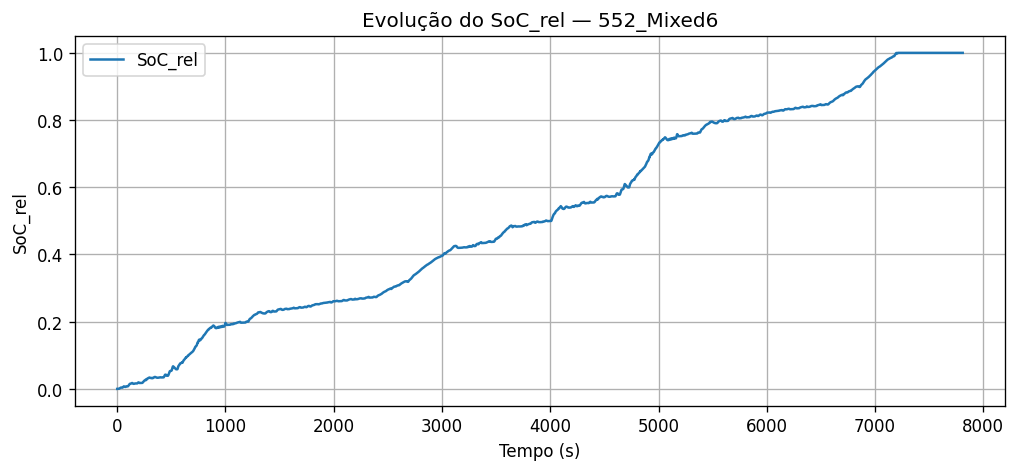

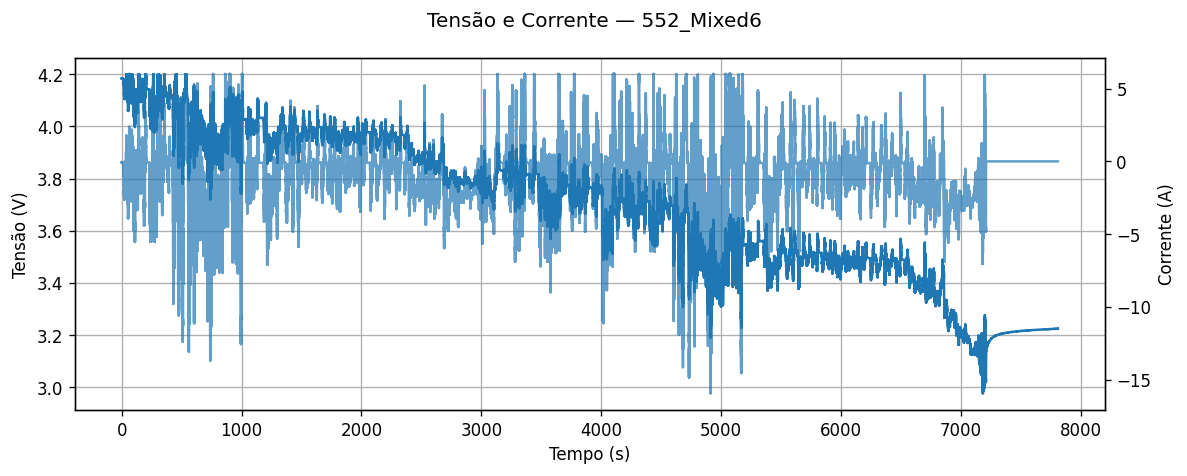

✔ Validação visual do SoC_rel concluída.


In [9]:
# === CÉLULA 5 — Validação gráfica do SoC_rel [KAGGLE SAFE] ===

import numpy as np
import matplotlib.pyplot as plt

print("=== VALIDAÇÃO DO SoC_rel (dataset completo LG HG2) ===")

print("\nIntervalo global do SoC_rel:")
print("Min:", float(df["soc_rel"].min()))
print("Max:", float(df["soc_rel"].max()))

if df["soc_rel"].min() < -0.05 or df["soc_rel"].max() > 1.05:
    print("⚠️ Aviso: SoC_rel fora do intervalo esperado!")
else:
    print("✔ SoC_rel dentro do intervalo normal (0–1).")

# Escolher um ficheiro típico (preferência por descarga: corrente média < 0)
file_stats = df.groupby("file_id")[col_current].mean().sort_values()
dis_files = file_stats[file_stats < 0].index.tolist()

if len(dis_files) > 0:
    example_file = dis_files[len(dis_files)//2]
else:
    example_file = file_stats.index[len(file_stats)//2]

print(f"\n📊 Exemplo de ficheiro para validação: {example_file}")

df_ex = df[df["file_id"] == example_file].sort_values("time_s")

# Plot SoC_rel
plt.figure(figsize=(10, 4))
plt.plot(df_ex["time_s"], df_ex["soc_rel"], label="SoC_rel")
plt.xlabel("Tempo (s)")
plt.ylabel("SoC_rel")
plt.title(f"Evolução do SoC_rel — {example_file}")
plt.grid(True)
plt.legend()
plt.show()

# Plot tensão e corrente
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(df_ex["time_s"], df_ex[col_voltage], label="Tensão (V)")
ax1.set_xlabel("Tempo (s)")
ax1.set_ylabel("Tensão (V)")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(df_ex["time_s"], df_ex[col_current], alpha=0.7, label="Corrente (A)")
ax2.set_ylabel("Corrente (A)")

fig.suptitle(f"Tensão e Corrente — {example_file}")
fig.tight_layout()
plt.show()

print("✔ Validação visual do SoC_rel concluída.")


### Análise dos Resultados — Validação do SoC_rel

A validação gráfica confirma que o SoC_rel evolui de forma monotónica e fisicamente coerente ao longo do tempo. Em ensaios de descarga, observa-se a diminuição progressiva do SoC, acompanhando o comportamento da corrente e da tensão.

A ausência de oscilações artificiais confirma a validade do método de reconstrução adotado.


In [10]:
#==carregar cache==

from pathlib import Path
import pandas as pd

p = Path("/kaggle/working/df_prepared.pkl")
if p.exists():
    df = pd.read_pickle(p)
    print("✔ df carregado do cache:", df.shape)
else:
    print("⚠️ Sem cache — corre as células 3 e 4.")


✔ df carregado do cache: (4954914, 20)


## 6. Random Forest para estimação de SoC

Agora treinamos um modelo **RandomForestRegressor** com:

**Features**
- Tensão (`voltage`)
- Corrente (`current`)
- Temperatura (`temperature`)
- Derivadas aproximadas: `dV/dt`, `dI/dt`

**Target**
- `soc_real` reconstruído.

O Random Forest é uma escolha adequada porque:
- Captura relações não-lineares tensão–corrente–temperatura–SoC.  
- É robusto a ruído experimental.  


OK — df existe e tem time_s + soc_rel. Colunas base detetadas.
Train: (477205, 5) Test: (99981, 5)
Treinando Random Forest...

=== Resultados Random Forest (SoC_rel) ===
MAE  : 0.0567
RMSE : 0.1311
R²   : 0.8455


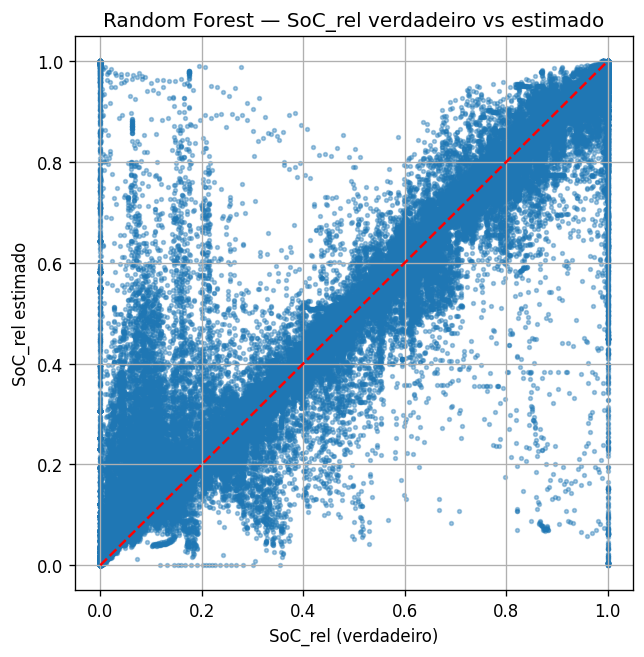

In [11]:
# === CÉLULA 6 — Features + treino Random Forest (SoC_rel) [KAGGLE SAFE] ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- CONFIRMAÇÕES (pedido) ---
if "df" not in globals():
    raise RuntimeError("df não existe. Corre primeiro as células 3 e 4.")
need_cols = {"file_id", "time_s", "soc_rel"}
miss = need_cols - set(df.columns)
if miss:
    raise RuntimeError(f"Faltam colunas em df: {miss}. Corre a Célula 4 (pré-processamento).")

for vname in ["col_voltage", "col_current", "col_temp"]:
    if vname not in globals() or globals()[vname] is None:
        raise RuntimeError(f"{vname} não está definido. Corre a Célula 4.")

print("OK — df existe e tem time_s + soc_rel. Colunas base detetadas.")

# 1) Ordenação temporal
df = df.sort_values(["file_id", "time_s"]).reset_index(drop=True)

# 2) Garantir numéricos
base_cols = [col_voltage, col_current, col_temp, "time_s", "soc_rel"]
for c in base_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) Derivadas temporais (por ficheiro)
dt = df.groupby("file_id")["time_s"].diff()

df["dv_dt"] = df.groupby("file_id")[col_voltage].diff() / dt
df["di_dt"] = df.groupby("file_id")[col_current].diff() / dt

df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 4) Features
feature_cols = [col_voltage, col_current, col_temp, "dv_dt", "di_dt"]

# incluir capacity só se existir e estiver definido
if "col_capacity" in globals() and col_capacity is not None and col_capacity in df.columns:
    df[col_capacity] = pd.to_numeric(df[col_capacity], errors="coerce")
    feature_cols.insert(3, col_capacity)  # entra antes das derivadas

# remover NaN das features + target
df = df.dropna(subset=feature_cols + ["soc_rel"]).reset_index(drop=True)

# (Opcional) reduzir memória
for c in feature_cols + ["soc_rel"]:
    df[c] = df[c].astype("float32")

# 5) Split por ficheiro (evita leakage)
file_ids = df["file_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(file_ids)

split = int(0.8 * len(file_ids))
train_ids = set(file_ids[:split])
test_ids  = set(file_ids[split:])

train_mask = df["file_id"].isin(train_ids)
test_mask  = df["file_id"].isin(test_ids)

X_train = df.loc[train_mask, feature_cols]
y_train = df.loc[train_mask, "soc_rel"]
X_test  = df.loc[test_mask, feature_cols]
y_test  = df.loc[test_mask, "soc_rel"]

print("Train:", X_train.shape, "Test:", X_test.shape)

# 6) Modelo
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

print("Treinando Random Forest...")
rf.fit(X_train, y_train)

# 7) Predições + métricas
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("\n=== Resultados Random Forest (SoC_rel) ===")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# 8) Parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.4)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("SoC_rel (verdadeiro)")
plt.ylabel("SoC_rel estimado")
plt.title("Random Forest — SoC_rel verdadeiro vs estimado")
plt.grid(True)
plt.show()


### Análise dos Resultados — Random Forest

O modelo Random Forest apresentou um desempenho sólido na estimação do SoC_rel, com R² ≈ 0,85, indicando elevada capacidade de explicação da variabilidade do estado de carga.

O erro médio absoluto reduzido confirma boa precisão global, enquanto o gráfico de paridade evidencia boa concordância entre valores estimados e reais, sobretudo nas regiões intermédias do SoC.


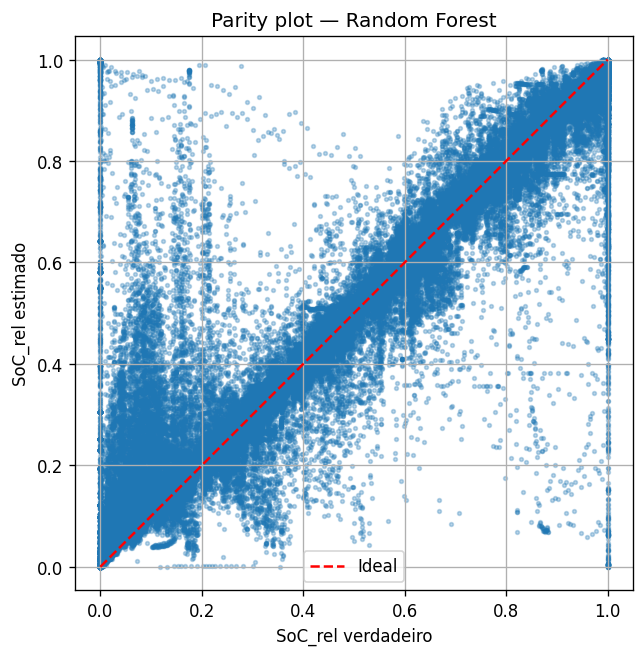

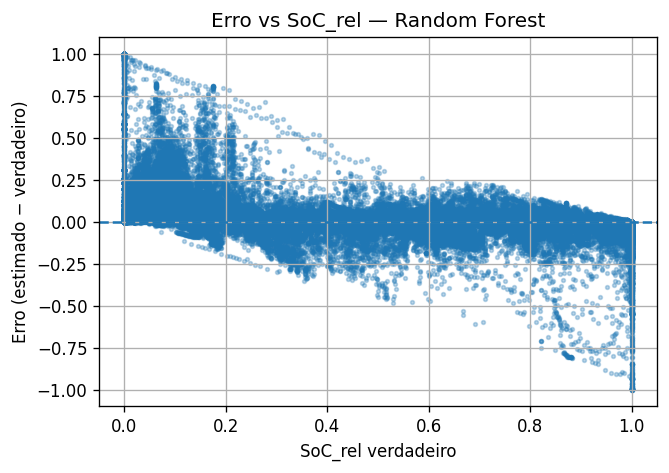

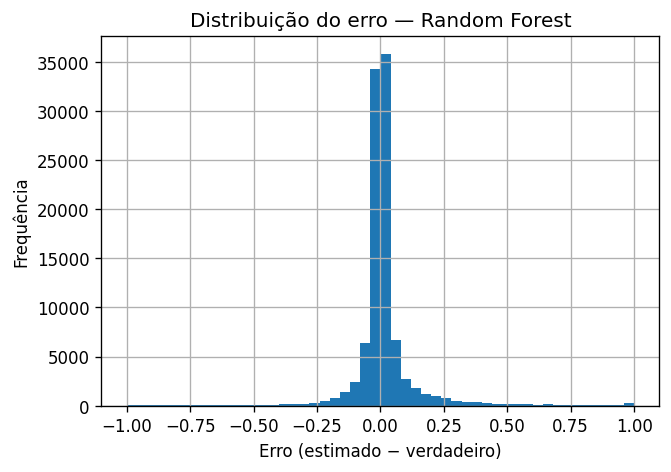

In [12]:
# === CÉLULA 6.1 — Diagnóstico gráfico do Random Forest [KAGGLE SAFE] ===

import matplotlib.pyplot as plt
import numpy as np

errors = y_pred - y_test

# 1) Parity plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, s=5, alpha=0.3)
plt.plot([0, 1], [0, 1], "r--", label="Ideal")
plt.xlabel("SoC_rel verdadeiro")
plt.ylabel("SoC_rel estimado")
plt.title("Parity plot — Random Forest")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

# 2) Erro vs SoC
plt.figure(figsize=(6, 4))
plt.scatter(y_test, errors, s=5, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("SoC_rel verdadeiro")
plt.ylabel("Erro (estimado − verdadeiro)")
plt.title("Erro vs SoC_rel — Random Forest")
plt.grid(True)
plt.show()

# 3) Histograma do erro
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=50)
plt.xlabel("Erro (estimado − verdadeiro)")
plt.ylabel("Frequência")
plt.title("Distribuição do erro — Random Forest")
plt.grid(True)
plt.show()


### Análise dos Resultados — Diagnóstico do Erro

A distribuição do erro encontra-se aproximadamente centrada em zero, indicando ausência de viés sistemático significativo. Observa-se maior dispersão do erro nas regiões extremas do SoC, comportamento comum em problemas de estimação de estado de carga.

No geral, o erro mantém-se controlado, confirmando a robustez do modelo.


## 7. (Opcional) Guardar modelo treinado

Guardamos o modelo Random Forest para uso futuro (por exemplo, conversão para implementação em microcontrolador/ESP32 em C/C++ ou árvores de decisão equivalentes).

In [13]:
# === CÉLULA 7 — Guardar modelo Random Forest (opcional) ===

import joblib

output_path = "rf_soc_dhakal_25degC.pkl"
joblib.dump(rf, output_path)

print(f"✔ Modelo Random Forest guardado em: {output_path}")

✔ Modelo Random Forest guardado em: rf_soc_dhakal_25degC.pkl
